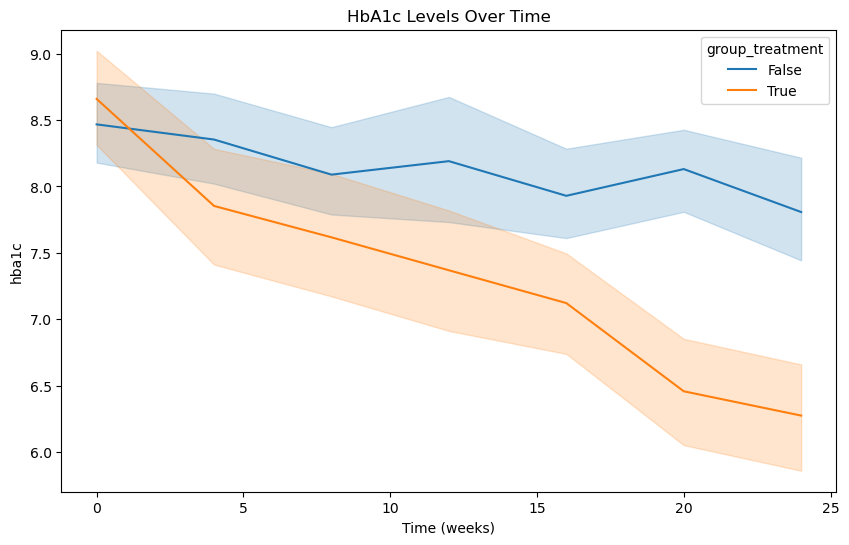

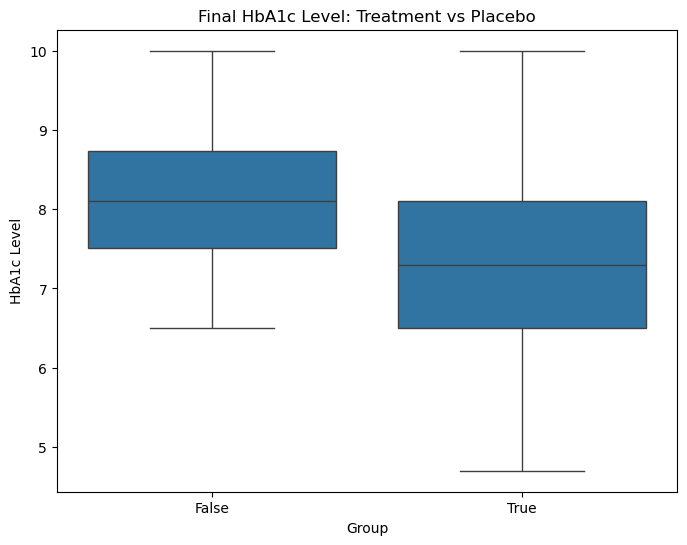

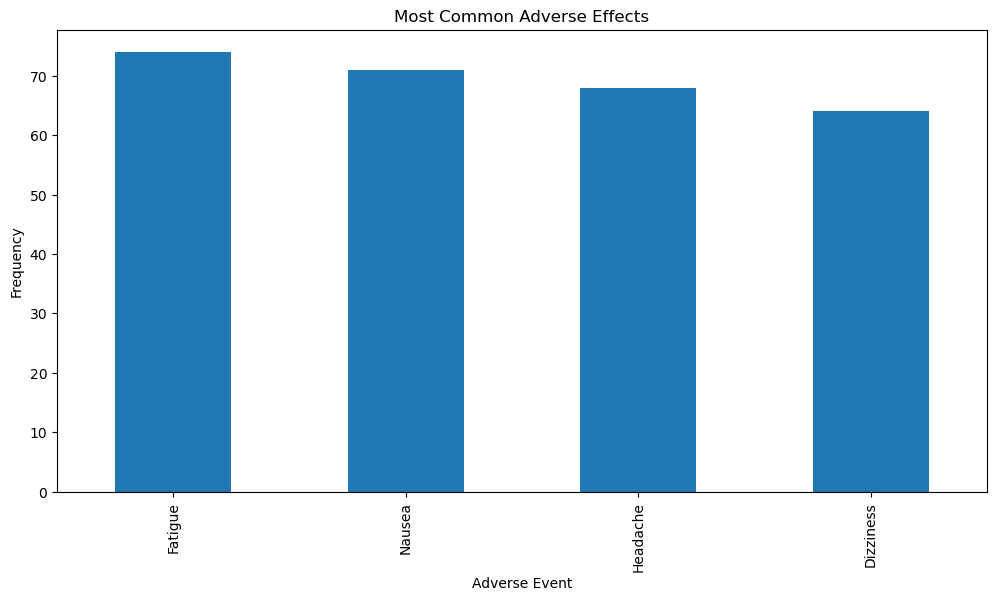

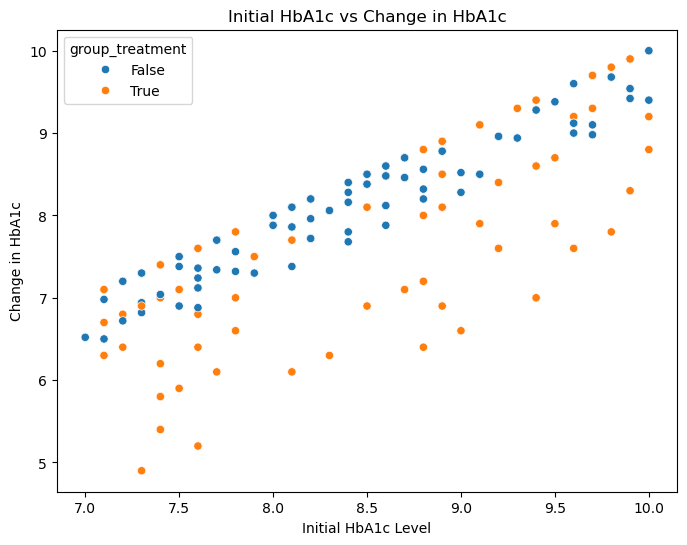

                     sum_sq     df          F        PR(>F)
group_treatment   43.836941    1.0  50.782549  9.143732e-12
time              64.254098    1.0  74.434639  5.169343e-16
Residual         236.524596  274.0        NaN           NaN
chi-square test result: chi2 = 3.453364951919518, p-value = 0.3268610889706339


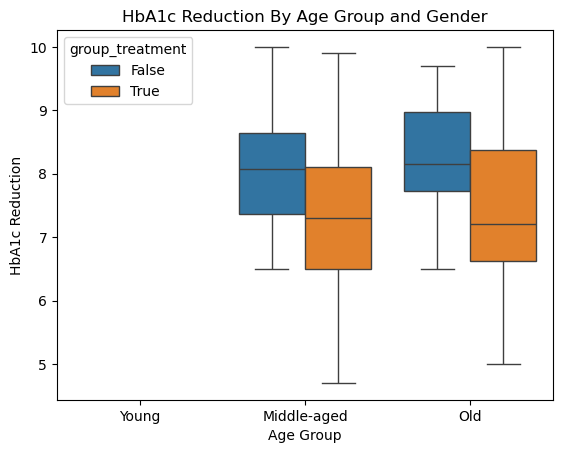

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Step 1 Load the dataset

df = pd.read_csv('/Users/Macbook/Documents/Jupyter/diabetes_medication_clinical_trial1_3.csv')

# df.head()
# df.info()
# df.describe()

# Step 2 Data Exploration

# print(f"DataFrame Shape: {df.shape}")

# Step 3 Data Cleaning
# print(f"Missing Values:\n{df.isnull().sum()}")

df = df.dropna()

df['time'] = pd.to_numeric(df['time'], errors='coerce')

# Convert 'group' to categorical
df['group'] = df['group'].astype('category')

df = pd.get_dummies(df, columns=['group'], drop_first=True)

df.rename(columns={'group_treatment': 'group_treatment'}, inplace=True)

# print(df.head())
# print(df.columns)

# Convert all columns used in  modeling to numeric types
df['group_treatment'] = pd.to_numeric(df['group_treatment'], errors='coerce')

df['time'] = pd.to_numeric(df['time'], errors='coerce')

df['hba1c'] = pd.to_numeric(df['hba1c'], errors='coerce')

avg_hba1c_treatment = df[df['group_treatment'] == 1]['hba1c'].mean()

avg_hba1c_placebo = df[df['group_treatment'] == 0]['hba1c'].mean()

# print(avg_hba1c_treatment)

# Calculate average HbA1c for the treatment group
# print(f"Average HbA1c for Treatment Group: {avg_hba1c_treatment}")
# print(f"Average HbA1c for Placebo Group: {avg_hba1c_placebo}")

# Calculate change in HbA1c for each subject
df['hba1c_change'] = df.groupby('subject_id')['hba1c'].transform(lambda x: x.iloc[0])

# Count occurences of each type of adverse events 

adverse_events = df['adverse_event'].value_counts(0)

# print(adverse_events)

plt.figure(figsize=(10, 6))
# Plot HbA1c levels over time with treatment group colour coding

sns.lineplot(x='time', y='hba1c', hue='group_treatment', data=df)
plt.title('HbA1c Levels Over Time') 

# Set the x-axis label
plt.xlabel('Time (weeks)') 

# Displays the plot
plt.show() 

plt.figure(figsize=(8, 6))
sns.boxplot(x='group_treatment', y='hba1c', data=df)
plt.title('Final HbA1c Level: Treatment vs Placebo')
plt.xlabel('Group')
plt.ylabel('HbA1c Level')
plt.show()

plt.figure(figsize=(12, 6))
adverse_events.plot(kind='bar')
plt.title('Most Common Adverse Effects')
plt.xlabel('Adverse Event')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='initial_hba1c', y='hba1c_change', hue='group_treatment', data=df)
plt.title('Initial HbA1c vs Change in HbA1c')
plt.xlabel('Initial HbA1c Level')
plt.ylabel('Change in HbA1c')
plt.show()

t_stat, p_val = stats.ttest_ind(df[df['group_treatment'] == 1]['hba1c'], df[df['group_treatment'] == 0]['hba1c'])
# print(f"T-test result: {t_stat}, p-value = {p_val}")

#Perfrom ANOVA usuing statsmodel formula API
model = smf.ols('hba1c ~ time + group_treatment', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)

# Use chi square test to compare adverse event rates between groups
adverse_event_table = pd.crosstab(df['group_treatment'], df['adverse_event'])

# Create a contingency table for adverse events by treatment group
chi2, p, dof, expected = stats.chi2_contingency(adverse_event_table, correction=False)
print(f"chi-square test result: chi2 = {chi2}, p-value = {p}")

if 'age_group' not in df.columns: # Check if age_group is missing
    df['age_group'] = pd.cut(df['age'], bins=[0, 30, 60, 90], labels=['Young', 'Middle-aged', 'Old'])
    
# Create a box plot for HbA1c by age group and treatment group    

sns.boxplot(x='age_group', y='hba1c', hue='group_treatment', data=df)
plt.title('HbA1c Reduction By Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('HbA1c Reduction')
plt.show()
